# EDA exploratorio del dataset SEXTANTE (muestra del 5%)

Objetivo: **conocer qué tenemos** en el dataset unificado `vacantes-colombia`
(la memoria persistente del proyecto, sincronizada con Hugging Face) mediante un
EDA simple y exploratorio sobre una **muestra aleatoria del 5%**.

Tomamos una muestra porque la población completa (SPE + corpus curado) ronda
los 250 mil registros; la muestra permite iterar rápido sin cargar todo y sirve
de punto de partida antes del EDA profundo (extracción de habilidades, salarios
por perfil, grafos).

- **Fuente de la muestra**: los shards parquet del dataset HF
  (`data/emitido/vacantes-colombia/`, 17 columnas canónicas + `almacen`).
- **Semilla fija** (`random_state=42`) para que el notebook sea reproducible.
- Procedencia: SPE (export oficial, fuente maestra) + corpus curado
  (El Empleo + LinkedIn). Ver `docs/viabilidad_fuentes.md`.


In [1]:
import sys
import glob
from collections import Counter
from pathlib import Path
import re

# Raíz del proyecto: funciona tanto si se ejecuta desde notebooks/ como desde la raíz.
RAIZ = Path.cwd()
if not (RAIZ / "data").exists():
    RAIZ = RAIZ.parent
sys.path.insert(0, str(RAIZ))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 30)

from src.extraccion.esquema import COLUMNAS_ESQUEMA, validar

SEED = 42
FRAC = 0.05

# Los shards del dataset HF pueden crecer; glob en lugar de rutas fijas.
SHARDS = sorted(glob.glob(str(RAIZ / "data/emitido/vacantes-colombia/data/train-*.parquet")))
print(f"shards encontrados: {len(SHARDS)}")
df = pd.concat([pd.read_parquet(f) for f in SHARDS], ignore_index=True)
print(f"dataset HF completo (población): {len(df):,} registros")

shards encontrados: 5


dataset HF completo (población): 246,782 registros


In [2]:
muestra = df.sample(frac=FRAC, random_state=SEED, ignore_index=True)
print(f"muestra: {len(muestra):,} registros = {len(muestra) / len(df):.2%} de la población")

comp = pd.DataFrame({
    "población": df["almacen"].value_counts(),
    "muestra": muestra["almacen"].value_counts(),
})
comp["población_%"] = (comp["población"] / comp["población"].sum() * 100).round(1)
comp["muestra_%"] = (comp["muestra"] / comp["muestra"].sum() * 100).round(1)
comp

muestra: 12,339 registros = 5.00% de la población


,población,muestra,población_%,muestra_%
almacen,,,,
spe,246551,12323,99.9,99.9
curado,231,16,0.1,0.1


## 1. Esquema canónico y tipos de dato

In [3]:
faltantes = validar(muestra)
print("columnas canónicas:", len(COLUMNAS_ESQUEMA))
print("columnas en la muestra:", list(muestra.columns))
print("faltantes:", faltantes if faltantes else "ninguna ✔")
print("shape:", muestra.shape)

columnas canónicas: 17
columnas en la muestra: ['id_vacante', 'portal', 'url', 'titulo', 'empresa', 'ciudad', 'departamento', 'fecha_publicacion', 'descripcion', 'salario_texto', 'salario_min', 'salario_max', 'tipo_contrato', 'modalidad', 'nivel_educativo', 'experiencia_texto', 'fecha_captura', 'almacen']
faltantes: ninguna ✔
shape: (12339, 18)


In [4]:
# Tipos por columna (las fechas/salarios se normalizan más adelante).
print(muestra.dtypes.to_string())
print()
muestra.head(3).T

id_vacante            object
portal                object
url                   object
titulo                object
empresa               object
ciudad                object
departamento          object
fecha_publicacion     object
descripcion           object
salario_texto         object
salario_min          float64
salario_max          float64
tipo_contrato         object
modalidad             object
nivel_educativo       object
experiencia_texto     object
fecha_captura         object
almacen               object



,0,1,2
id_vacante,spe-950330,spe-65928915,spe-65806097
portal,spe,spe,spe
url,https://www.magneto365.com/co/empleos/requerim...,https://go.computrabajo.com/go/gom?url=https%3...,https://go.computrabajo.com/go/gom?url=https%3...
titulo,Requerimos mensajero motorizado Bogota,237334 Asesor/a de servicio al cliente chat + ...,Asesor Servicio al Cliente / Entidad Bancaria
empresa,MAGNETO GLOBAL S.A.S.,COMPUTRABAJO,COMPUTRABAJO
ciudad,"BOGOTÁ, D.C.","BOGOTÁ, D.C.","BOGOTÁ, D.C."
departamento,"BOGOTÁ, D.C.","BOGOTÁ, D.C.","BOGOTÁ, D.C."
fecha_publicacion,2026-06-12T00:00:00.000Z,2026-08-23T00:00:00.000Z,2026-08-12T00:00:00.000Z
descripcion,Importante empresa de tecnologia requiere pers...,Tu talento tiene el poder de crear experiencia...,VACANTE ASESOR SERVICIO AL CLIENTE Función: At...
salario_texto,$1.500.001 - $2.000.000,$1.500.001 - $2.000.000,$1.500.001 - $2.000.000


## 2. Cobertura de campos (nulos)

El SPE cubre ~100% de los campos estructurados; el corpus curado (El Empleo +
LinkedIn) es minúsculo (~0.1% de la población), así que su ausencia casi no se
nota en la muestra. Aquí vemos el panorama agregado y por almacén.


In [5]:
cobertura = pd.DataFrame({
    "no_nulos": muestra.notna().sum(),
    "cobertura_%": (muestra.notna().mean() * 100).round(1),
}).sort_values("cobertura_%", ascending=False)
cobertura

,no_nulos,cobertura_%
id_vacante,12339,100.0
portal,12339,100.0
url,12339,100.0
titulo,12339,100.0
empresa,12339,100.0
ciudad,12335,100.0
fecha_publicacion,12339,100.0
descripcion,12337,100.0
salario_texto,12334,100.0
tipo_contrato,12337,100.0


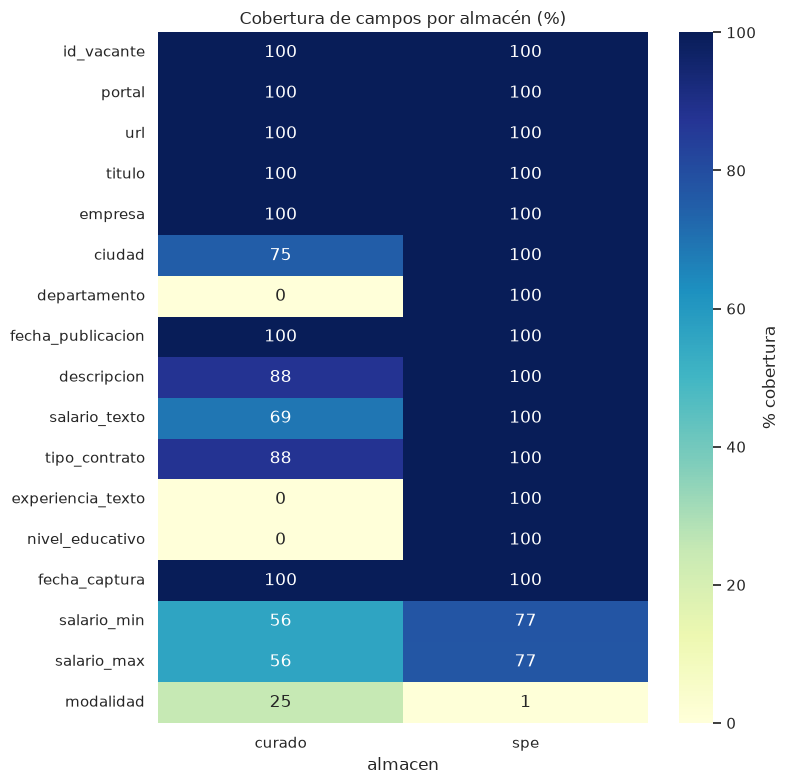

almacen,curado,spe
id_vacante,100.0,100.0
portal,100.0,100.0
url,100.0,100.0
titulo,100.0,100.0
empresa,100.0,100.0
ciudad,75.0,100.0
departamento,0.0,100.0
fecha_publicacion,100.0,100.0
descripcion,87.5,100.0
salario_texto,68.8,100.0


In [6]:
# Cobertura por almacén (SPE vs curado) para ver dónde diverge la calidad.
cols_esquema = COLUMNAS_ESQUEMA
cov_por_almacen = (
    muestra.groupby("almacen")[cols_esquema]
    .apply(lambda g: (g.notna().mean() * 100).round(1))
    .T
    .sort_values(by="spe", ascending=False)
)

plt.figure(figsize=(8, 8))
sns.heatmap(cov_por_almacen, annot=True, fmt=".0f", cmap="YlGnBu",
            cbar_kws={"label": "% cobertura"})
plt.title("Cobertura de campos por almacén (%)")
plt.tight_layout()
plt.show()
cov_por_almacen

## 3. Composición: almacén y portal

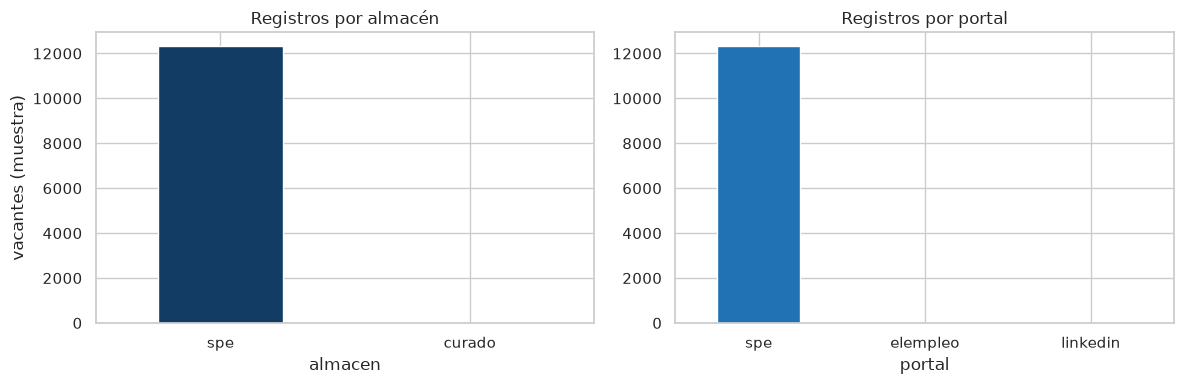

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
muestra["almacen"].value_counts().plot(kind="bar", ax=axes[0], color=["#123c63", "#e8b93a"])
axes[0].set_title("Registros por almacén")
axes[0].set_ylabel("vacantes (muestra)")
axes[0].tick_params(axis="x", rotation=0)

portal = muestra["portal"].value_counts()
portal.plot(kind="bar", ax=axes[1], color=sns.color_palette("Blues_r", n_colors=len(portal)))
axes[1].set_title("Registros por portal")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

## 4. Temporalidad (fecha de publicación)

/tmp/ipykernel_13058/250440477.py:5: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  muestra["anio_mes"] = muestra["fecha_publicacion"].dt.to_period("M")


periodo de publicación: 2024-09-20 00:00:00+00:00 → 2026-09-16 00:00:00+00:00
días publicación→captura: mediana 32.0 | p90 60.0


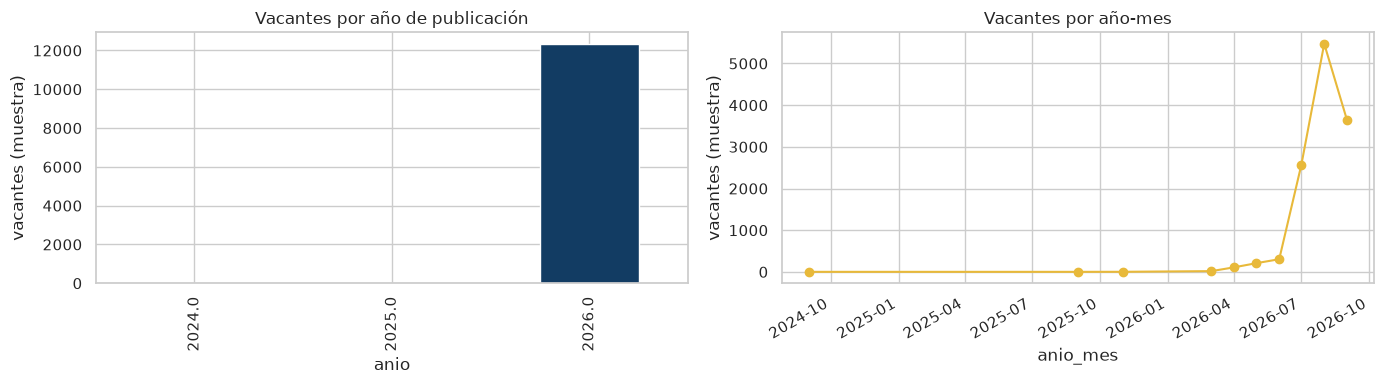

In [8]:
# fechas: ambas a tz-aware UTC para poder restar sin errores.
muestra["fecha_publicacion"] = pd.to_datetime(muestra["fecha_publicacion"], errors="coerce", utc=True)
muestra["fecha_captura"] = pd.to_datetime(muestra["fecha_captura"], errors="coerce", utc=True)
muestra["anio"] = muestra["fecha_publicacion"].dt.year
muestra["anio_mes"] = muestra["fecha_publicacion"].dt.to_period("M")

print("periodo de publicación:", muestra["fecha_publicacion"].dropna().min(), "→",
      muestra["fecha_publicacion"].dropna().max())
lag = (muestra["fecha_captura"] - muestra["fecha_publicacion"]).dt.days
print("días publicación→captura: mediana", lag.median(), "| p90", lag.quantile(0.9))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
por_anio = muestra["anio"].value_counts().sort_index()
por_anio.plot(kind="bar", ax=axes[0], color="#123c63")
axes[0].set_title("Vacantes por año de publicación")
axes[0].set_ylabel("vacantes (muestra)")

por_mes = muestra.groupby("anio_mes").size()
por_mes = por_mes.reindex(por_mes.index)  # conserva PeriodIndex
por_mes.index = por_mes.index.to_timestamp()
por_mes.plot(kind="line", ax=axes[1], marker="o", color="#e8b93a")
axes[1].set_title("Vacantes por año-mes")
axes[1].set_ylabel("vacantes (muestra)")

plt.tight_layout()
plt.show()

## 5. Geografía

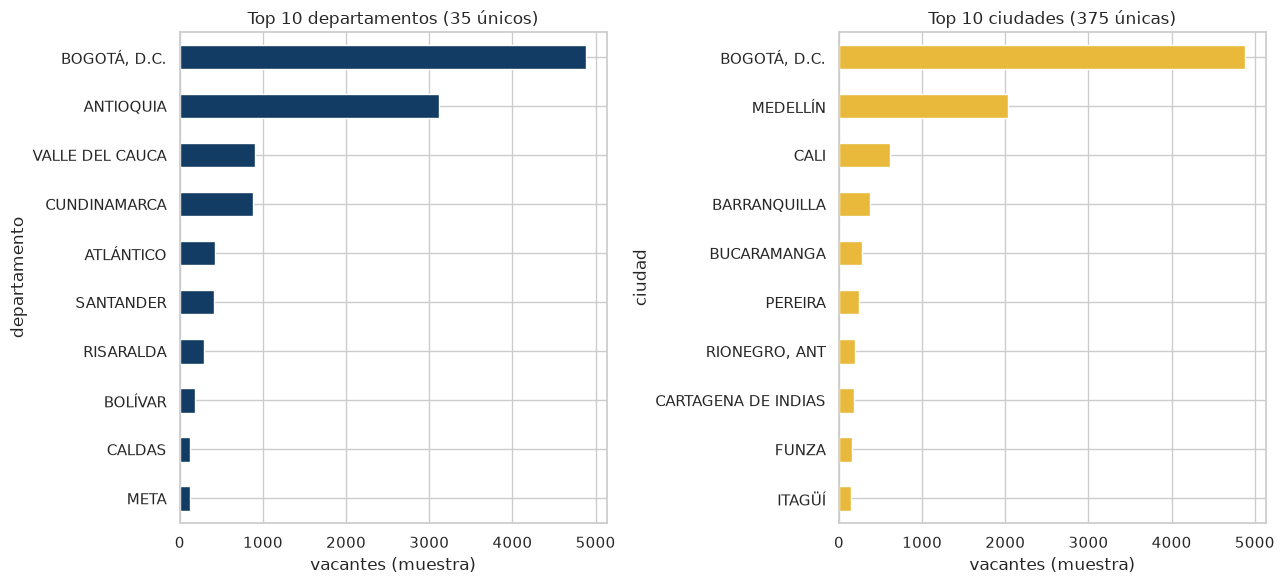

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

top_dept = muestra["departamento"].value_counts().head(10)
top_dept.sort_values().plot(kind="barh", ax=axes[0], color="#123c63")
axes[0].set_title(f"Top 10 departamentos ({len(muestra['departamento'].unique()):,} únicos)")
axes[0].set_xlabel("vacantes (muestra)")

top_ciudad = muestra["ciudad"].value_counts().head(10)
top_ciudad.sort_values().plot(kind="barh", ax=axes[1], color="#e8b93a")
axes[1].set_title(f"Top 10 ciudades ({len(muestra['ciudad'].unique()):,} únicas)")
axes[1].set_xlabel("vacantes (muestra)")

plt.tight_layout()
plt.show()

## 6. Estructura de la oferta (contrato, modalidad, educación, experiencia)

In [10]:
def tab(series, n=8, titulo=None):
    vc = series.value_counts(dropna=False).head(n)
    out = pd.DataFrame({"n": vc, "%": (vc / len(series) * 100).round(1)})
    if titulo:
        print(f"### {titulo}")
    return out

tab(muestra["tipo_contrato"], titulo="Tipo de contrato")

### Tipo de contrato


,n,%
tipo_contrato,,
Por obra o labor,5167,41.9
Término indefinido,3895,31.6
Término fijo,2644,21.4
Otra,338,2.7
Prestación de servicios,263,2.1
Temporal,19,0.2
Tiempo completo,6,0.0
Por día,5,0.0


In [11]:
tab(muestra["modalidad"], n=5, titulo="Modalidad")

### Modalidad


,n,%
modalidad,,
None,12249,99.3
Teletrabajo,86,0.7
Remoto,4,0.0


In [12]:
tab(muestra["nivel_educativo"], titulo="Nivel educativo")

### Nivel educativo


,n,%
nivel_educativo,,
Media,4320,35.0
Técnico,2768,22.4
Universitarios,2161,17.5
Tecnólogico,1250,10.1
Básica Secundaria,694,5.6
No Aplica,344,2.8
Primaria,315,2.6
Especilización,291,2.4


experiencia requerida (meses): mediana 12 · media 22.8 · máx 999


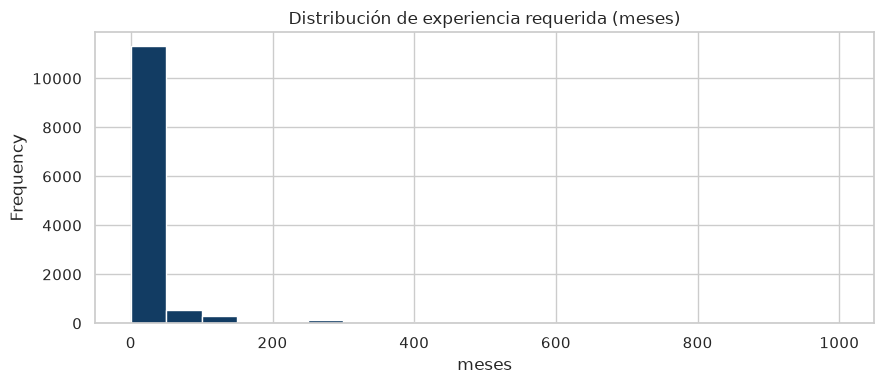

In [13]:
# experiencia_texto viene como "X meses"; extraemos el número.
exp = pd.to_numeric(muestra["experiencia_texto"].str.extract(r"(\d+)", expand=False), errors="coerce")
print("experiencia requerida (meses):",
      f"mediana {exp.median():.0f} · media {exp.mean():.1f} · máx {exp.max():.0f}")

plt.figure(figsize=(9, 4))
exp.dropna().plot(kind="hist", bins=20, color="#123c63", edgecolor="white")
plt.title("Distribución de experiencia requerida (meses)")
plt.xlabel("meses")
plt.tight_layout()
plt.show()

## 7. Salarios

In [14]:
sal = muestra[["salario_min", "salario_max"]].apply(pd.to_numeric, errors="coerce")
con_sal = sal["salario_min"].notna().mean()
print(f"salario numérico disponible en {con_sal:.1%} de la muestra")
print("descriptivos (COP):")
sal.describe().round(0)

salario numérico disponible en 77.4% de la muestra
descriptivos (COP):


,salario_min,salario_max
count,9546.0,9525.0
mean,1943419.0,2650453.0
std,1176079.0,1367089.0
min,589500.0,884250.0
25%,1500001.0,2000000.0
50%,1500001.0,2000000.0
75%,2000001.0,3000000.0
max,15000001.0,15000000.0


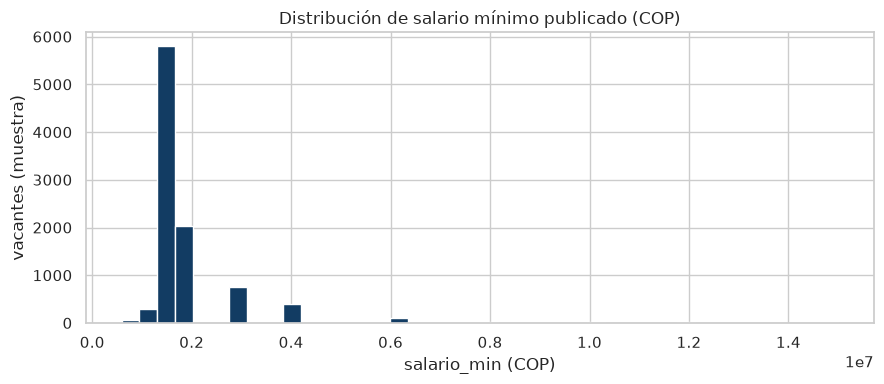

In [15]:
plt.figure(figsize=(9, 4))
sal["salario_min"].dropna().plot(kind="hist", bins=40, color="#123c63", edgecolor="white")
plt.title("Distribución de salario mínimo publicado (COP)")
plt.xlabel("salario_min (COP)")
plt.ylabel("vacantes (muestra)")
plt.tight_layout()
plt.show()

In [16]:
# Relación salario mínimo ~ nivel educativo (premium educativo).
med_sal = muestra.assign(smin=sal["salario_min"]).groupby("nivel_educativo")["smin"].median()
med_sal.sort_values(ascending=False)

nivel_educativo
Especilización       4000001.0
Doctorado            3000001.0
Maestria             3000001.0
Universitarios       2000001.0
Tecnólogico          2000001.0
Básica Secundaria    1500001.0
Media                1500001.0
Otro                 1500001.0
No Aplica            1500001.0
Primaria             1500001.0
Técnico              1500001.0
Name: smin, dtype: float64

In [17]:
print("ejemplos de salario_texto (corpus curado):")
print(muestra.loc[muestra["almacen"] == "curado", "salario_texto"].dropna().head(5).to_string(index=False))

ejemplos de salario_texto (corpus curado):
  $2 a $2,5 millones
  $4 a $4,5 millones
Salario confidencial
  $2 a $2,5 millones
Salario confidencial


## 8. Descripciones (texto libre)

In [18]:
long = muestra["descripcion"].dropna().astype(str).str.len()
print(f"descripciones no vacías: {muestra['descripcion'].notna().sum()}")
print(f"largo: mediana {long.median():.0f} caracteres · máx {long.max():.0f}")

print()
print("ejemplos de título:")
for t in muestra["titulo"].dropna().head(3):
    print(" •", t[:110])

descripciones no vacías: 12337
largo: mediana 997 caracteres · máx 3280

ejemplos de título:
 • Requerimos mensajero motorizado Bogota
 • 237334 Asesor/a de servicio al cliente chat + voz Ingresas contratado/a, Sector financiero - posibilidad de te
 • Asesor Servicio al Cliente / Entidad Bancaria


In [19]:
stop = {"para", "que", "los", "las", "del", "una", "con", "por", "como",
        "de", "la", "el", "en", "y", "a", "se", "su", "sus", "un",
        "nuestro", "nuestra", "con", "todo", "son", "mas", "más", "sobre"}

palabras = Counter()
for d in muestra["descripcion"].dropna().astype(str):
    palabras.update(re.findall(r"[a-záéíóúñü]{4,}", d.lower()))

pal_filt = Counter({k: v for k, v in palabras.items() if k not in stop})
pal_filt.most_common(15)

[('experiencia', 16198),
 ('trabajo', 8074),
 ('equipo', 7711),
 ('salario', 6393),
 ('empresa', 6278),
 ('funciones', 6005),
 ('servicio', 5259),
 ('manejo', 5191),
 ('sector', 5180),
 ('realizar', 4950),
 ('contrato', 4837),
 ('cliente', 4759),
 ('ventas', 4605),
 ('procesos', 4496),
 ('cumplimiento', 4442)]

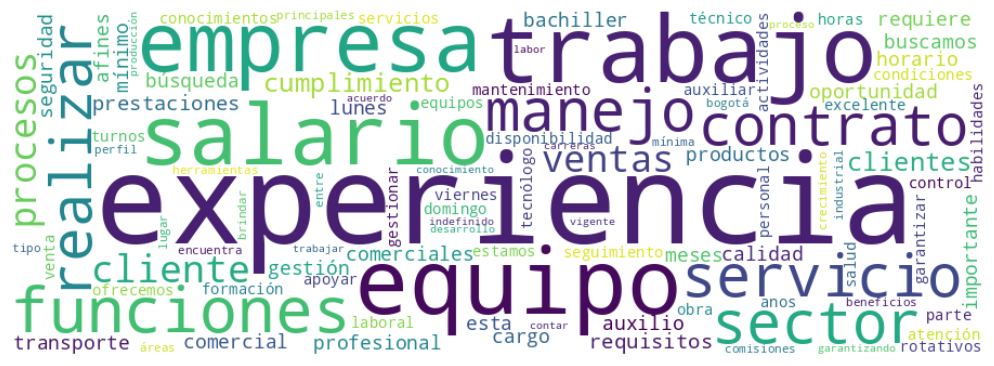

In [20]:
# Nube de palabras sobre las 100 más frecuentes de las descripciones.
try:
    from wordcloud import WordCloud

    wc = WordCloud(width=900, height=320, background_color="white",
                   max_words=100, random_state=SEED).generate_from_frequencies(pal_filt)
    plt.figure(figsize=(13, 4.5))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.show()
except ImportError:
    print("wordcloud no instalado; se omite la nube de palabras.")

In [21]:
# Mismas palabras clave, pero sobre los títulos.
pal_titulo = Counter()
for t in muestra["titulo"].dropna().astype(str):
    pal_titulo.update(re.findall(r"[a-záéíóúñü]{4,}", t.lower()))

pal_titulo_filt = Counter({k: v for k, v in pal_titulo.items() if k not in stop})
pal_titulo_filt.most_common(12)

[('auxiliar', 2263),
 ('asesor', 1601),
 ('comercial', 1499),
 ('experiencia', 1067),
 ('bogotá', 763),
 ('center', 740),
 ('analista', 738),
 ('call', 703),
 ('sector', 557),
 ('inmediata', 552),
 ('ventas', 547),
 ('operario', 526)]

## 9. Empresas

empresas distintas en la muestra: 247


/tmp/ipykernel_13058/2497405146.py:8: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


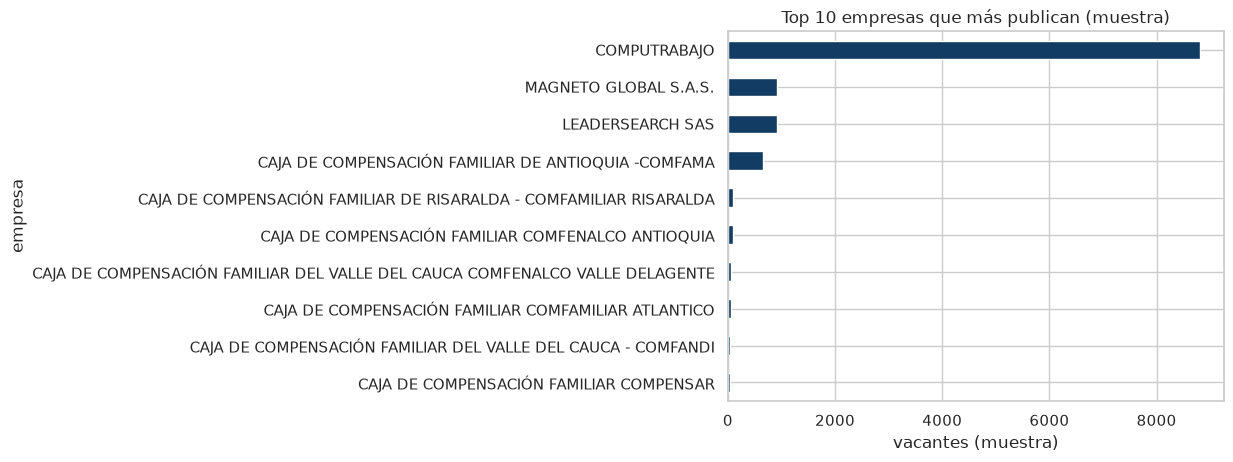

In [22]:
print(f"empresas distintas en la muestra: {muestra['empresa'].nunique():,}")

top_emp = muestra["empresa"].value_counts().head(10)
top_emp.plot(kind="barh", color="#123c63")
plt.title("Top 10 empresas que más publican (muestra)")
plt.xlabel("vacantes (muestra)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 10. Resumen de qué hay en la muestra

In [23]:
print(f"Muestra {len(muestra):,} (5.0% fija, semilla {SEED}) de {len(df):,} registros del dataset HF.")
print()
print(f"· Almacén:     {muestra['almacen'].value_counts().to_dict()}")
print(f"· Portal:      {muestra['portal'].value_counts().to_dict()}")
print(f"· Periodo:     {muestra['fecha_publicacion'].dropna().min().date()} → {muestra['fecha_publicacion'].dropna().max().date()}")
print(f"· Departamentos: {muestra['departamento'].nunique():,} · Ciudades: {muestra['ciudad'].nunique():,}")
print(f"· Cobertura clave:")
print(f"    - descripción: {muestra['descripcion'].notna().mean():.1%}")
print(f"    - salario numérico: {sal['salario_min'].notna().mean():.1%}")
print(f"    - nivel educativo: {muestra['nivel_educativo'].notna().mean():.1%}")
print(f"    - modalidad: {muestra['modalidad'].notna().mean():.1%}")
print()
print("Lectura rápida:")
print(" · El mercado de la muestra está dominado por Bogotá/Antioquia, contrato")
print("   'por obra o labor' y 'término indefinido', nivel educativo media/técnico,")
print("   experiencia 0-12 meses y salario mínimo alrededor del SMLV.")
print(" · La fuente maestra (SPE) da cobertura casi total de campos estructurados;")
print("   el corpus curado es residual en la muestra (~16 filas) y no permite")
print("   comparaciones por sí solo (analizar aparte).")

Muestra 12,339 (5.0% fija, semilla 42) de 246,782 registros del dataset HF.

· Almacén:     {'spe': 12323, 'curado': 16}
· Portal:      {'spe': 12323, 'elempleo': 11, 'linkedin': 5}
· Periodo:     2024-09-20 → 2026-09-16
· Departamentos: 34 · Ciudades: 374
· Cobertura clave:
    - descripción: 100.0%
    - salario numérico: 77.4%
    - nivel educativo: 99.9%
    - modalidad: 0.7%

Lectura rápida:
 · El mercado de la muestra está dominado por Bogotá/Antioquia, contrato
   'por obra o labor' y 'término indefinido', nivel educativo media/técnico,
   experiencia 0-12 meses y salario mínimo alrededor del SMLV.
 · La fuente maestra (SPE) da cobertura casi total de campos estructurados;
   el corpus curado es residual en la muestra (~16 filas) y no permite
   comparaciones por sí solo (analizar aparte).
